# Utils Tests

- Creation : *04/04/2024*
- Mise à jour : *16/12/2024*

Chargement d'un modèle préentrainé (AlexNet, VGG16, ...) et visualisation des activations intermédiaires (dont les cartes de caractéristiques).

## Modules

In [1]:
import os
import json
import math
from functools import partial
from typing import Any, Tuple, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.utils import make_grid
import torchvision.transforms as T
import torchvision.transforms.functional as F
from torchvision.io import read_image

from torchinfo import summary
#plt.rcParams["savefig.bbox"] = 'tight'

## Device

In [2]:
################@
def get_best_device():
    if torch.cuda.is_available():
        # move models to GPU
        device = torch.device("cuda")
        print('CUDA GPU available for training. Models moved to CUDA GPU')
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print('MPS GPU available for training. Models moved to MPS GPU')
    else:
        device = torch.device("cpu")
        print('Training on CPU')
    return device
device = get_best_device()

MPS GPU available for training. Models moved to MPS GPU


## Utils

### `show_images`

source : [Pytorch Doc - Visualization utilities](https://pytorch.org/vision/main/auto_examples/others/plot_visualization_utils.html#sphx-glr-auto-examples-others-plot-visualization-utils-py)

idée : ajouter la gestion des lignes

> UTILE ?

In [3]:
def show_images(images, title=""):
    """ Display a raw of images"""
    if not isinstance(images, list):
        images = [images]
    fig, axs = plt.subplots(ncols=len(images), squeeze=False)
    for i, img in enumerate(images):
        #img = img.detach()
        #img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### `get_conv_def`

Retourne un dictionnaire des principaux paramètres d'un module PyTorch Conv2d

In [4]:
def get_conv_def(conv: nn.Conv2d) -> dict:
    """ """
    get_keys = ["in_channels", "out_channels", "kernel_size", "stride", "padding", "padding_mode", "dilation", "bias"]
    values = vars(conv)
    return {k:(values[k] if k in values else None) for k in get_keys}

### `conv2d_output_size`

Calcul de la taille de la sortie d'un conv2d selon ses paramètres et la taille de l'entrée

In [5]:
def conv2d_output_size(
        input_size: int|Tuple[int, int],
        kernel_size: int|Tuple[int, int],
        padding_size: int|Tuple[int, int]=0,
        stride_size: int|Tuple[int, int]=1,
        dilation_size: int|Tuple[int, int]=1,
        pooling_size: int|Tuple[int, int]=1
        ):
    """ """
    _to_tuple = lambda v: (v, v)
    
    if type(input_size) == int:
        input_size = _to_tuple(input_size)
    elif type(input_size) == dict:
        input_size = (input_size["height"], input_size["width"])
    
    if type(kernel_size) == int:
        kernel_size = _to_tuple(kernel_size)
    
    if type(padding_size) == int:
        padding_size = _to_tuple(padding_size)

    if type(stride_size) == int:
        stride_size = _to_tuple(stride_size)
    
    if type(dilation_size) == int:
        dilation_size = _to_tuple(dilation_size)
    
    if type(pooling_size) == int:
        pooling_size = _to_tuple(pooling_size)

    output_size = lambda i: math.floor((
         (input_size[i] + 2 * padding_size[i] - dilation_size[i] * (kernel_size[i] - 1) - 1) / stride_size[i] + 1) / pooling_size[i]
         )
    output_size_h = output_size(0)
    output_size_w = output_size(1)
    return {"height": output_size_h, "width": output_size_w}

## Modèles

In [6]:
cnn_models = {}

### Alexnet + IMAGENET1K_V1

source(s): 
- https://pytorch.org/vision/stable/models/generated/torchvision.models.alexnet.html#torchvision.models.AlexNet_Weights
- https://pytorch.org/hub/pytorch_vision_alexnet/

In [7]:
cnn_models["alexet"] = models.alexnet(weights='IMAGENET1K_V1')
cnn_models["alexet"].eval()
cnn_models["alexet"].features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU(inplace=True)
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU(inplace=True)
  (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU(inplace=True)
  (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [8]:
#type(model.features[0])
#vars(model.features[0])
#model.features[0].weight.size()
cnn_models["alexet"].features[3].weight.size()

torch.Size([192, 64, 5, 5])

In [9]:
vars(cnn_models["alexet"].features[3])

{'training': False,
 '_parameters': OrderedDict([('weight',
               Parameter containing:
               tensor([[[[ 3.6245e-03,  1.4335e-03,  3.7217e-02, -2.0926e-02,  1.8121e-03],
                         [ 2.4126e-02, -1.2056e-02,  7.1170e-02, -8.5224e-02,  1.3067e-02],
                         [ 2.0966e-02, -1.0623e-01,  2.1572e-02, -6.9547e-02,  3.1583e-02],
                         [-8.3392e-03, -3.9020e-02, -4.6621e-02,  2.2133e-02, -1.3252e-03],
                         [-1.5370e-02,  8.6569e-03,  3.1479e-02,  1.6698e-02, -4.7130e-03]],
               
                        [[-5.4573e-03, -1.9087e-02, -3.2424e-02, -2.2006e-02, -1.2120e-02],
                         [-7.4972e-03,  3.0946e-02,  3.1899e-02, -7.6327e-03, -1.4720e-02],
                         [ 5.4830e-03,  8.0306e-02,  6.1262e-02,  1.3252e-02,  2.6240e-02],
                         [-2.6938e-02,  5.9188e-03,  3.8373e-02, -6.3116e-03,  3.9863e-03],
                         [ 2.0844e-03, -3.6292e-02, -2.198

In [10]:
summary(cnn_models["alexet"], input_size=torch.Size([1, 3, 224, 224]))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 1000]                 --
├─Sequential: 1-1                        [1, 256, 6, 6]            --
│    └─Conv2d: 2-1                       [1, 64, 55, 55]           23,296
│    └─ReLU: 2-2                         [1, 64, 55, 55]           --
│    └─MaxPool2d: 2-3                    [1, 64, 27, 27]           --
│    └─Conv2d: 2-4                       [1, 192, 27, 27]          307,392
│    └─ReLU: 2-5                         [1, 192, 27, 27]          --
│    └─MaxPool2d: 2-6                    [1, 192, 13, 13]          --
│    └─Conv2d: 2-7                       [1, 384, 13, 13]          663,936
│    └─ReLU: 2-8                         [1, 384, 13, 13]          --
│    └─Conv2d: 2-9                       [1, 256, 13, 13]          884,992
│    └─ReLU: 2-10                        [1, 256, 13, 13]          --
│    └─Conv2d: 2-11                      [1, 256, 13, 13]         

In [11]:
summary(cnn_models["alexet"].features, input_size=torch.Size([1, 3, 224, 224]))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 256, 6, 6]            --
├─Conv2d: 1-1                            [1, 64, 55, 55]           23,296
├─ReLU: 1-2                              [1, 64, 55, 55]           --
├─MaxPool2d: 1-3                         [1, 64, 27, 27]           --
├─Conv2d: 1-4                            [1, 192, 27, 27]          307,392
├─ReLU: 1-5                              [1, 192, 27, 27]          --
├─MaxPool2d: 1-6                         [1, 192, 13, 13]          --
├─Conv2d: 1-7                            [1, 384, 13, 13]          663,936
├─ReLU: 1-8                              [1, 384, 13, 13]          --
├─Conv2d: 1-9                            [1, 256, 13, 13]          884,992
├─ReLU: 1-10                             [1, 256, 13, 13]          --
├─Conv2d: 1-11                           [1, 256, 13, 13]          590,080
├─ReLU: 1-12                             [1, 256, 13, 13]    

## Accès à des images extraites de ImageNet
source(s) :
- https://github.com/EliSchwartz/imagenet-sample-images
- https://huggingface.co/datasets/imagenet-1k/viewer/default/validation

In [12]:
with open("imagenet_labels.json") as f:
    labels = json.load(f)
labels

{'0': 'tench, Tinca tinca',
 '1': 'goldfish, Carassius auratus',
 '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 '3': 'tiger shark, Galeocerdo cuvieri',
 '4': 'hammerhead, hammerhead shark',
 '5': 'electric ray, crampfish, numbfish, torpedo',
 '6': 'stingray',
 '7': 'cock',
 '8': 'hen',
 '9': 'ostrich, Struthio camelus',
 '10': 'brambling, Fringilla montifringilla',
 '11': 'goldfinch, Carduelis carduelis',
 '12': 'house finch, linnet, Carpodacus mexicanus',
 '13': 'junco, snowbird',
 '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea',
 '15': 'robin, American robin, Turdus migratorius',
 '16': 'bulbul',
 '17': 'jay',
 '18': 'magpie',
 '19': 'chickadee',
 '20': 'water ouzel, dipper',
 '21': 'kite',
 '22': 'bald eagle, American eagle, Haliaeetus leucocephalus',
 '23': 'vulture',
 '24': 'great grey owl, great gray owl, Strix nebulosa',
 '25': 'European fire salamander, Salamandra salamandra',
 '26': 'common newt, Triturus vulga

255


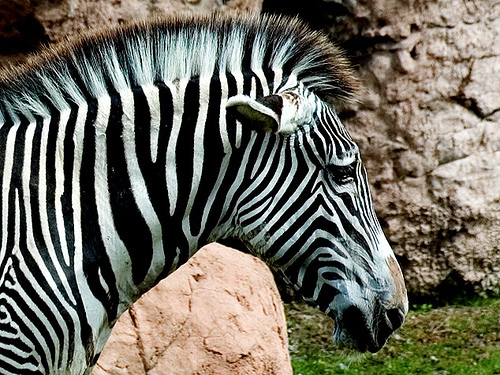

In [13]:
DataPath = "/Users/me/Documents/Work/Dev/_data/imagenet-sample-images-master"
ImageFile = "n02391049_zebra.JPEG"
filename = os.path.join(DataPath, ImageFile)
input_image = read_image(filename)
img = T.functional.to_pil_image(input_image)

print(input_image.max().item())
img

In [14]:
# Source : https://pytorch.org/vision/main/models/generated/torchvision.models.alexnet.html
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]